In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np

# Loading Dataset and Selecting Variables

In [34]:
# Read in data
data = pd.read_csv("D:\DataProjects\WGU\Resources\churn_clean.csv")

In [35]:
print('Total Null Values: ',data.isnull().sum().sum())
data.columns

Total Null Values:  0


Index(['CaseOrder', 'Customer_id', 'Interaction', 'UID', 'City', 'State',
       'Abbreviation', 'County', 'Zip', 'Lat', 'Lng', 'Population', 'Area',
       'TimeZone', 'Job', 'Children', 'Age', 'Income', 'Marital', 'Gender',
       'Churn', 'Outage_sec_perweek', 'Email', 'Contacts',
       'Yearly_equip_failure', 'Techie', 'Contract', 'Port_modem', 'Tablet',
       'InternetService', 'Phone', 'Multiple', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'PaperlessBilling', 'PaymentMethod', 'Tenure',
       'MonthlyCharge', 'Bandwidth_GB_Year', 'Item1', 'Item2', 'Item3',
       'Item4', 'Item5', 'Item6', 'Item7', 'Item8'],
      dtype='object')

In [36]:
#Selecting Variables
cols = ["Children", "Multiple", "Tenure",
        "StreamingMovies", "StreamingTV","Churn","InternetService",'Bandwidth_GB_Year']  
data = data[cols]

In [37]:
data.head()

,Children,Multiple,Tenure,StreamingMovies,StreamingTV,Churn,InternetService,Bandwidth_GB_Year
0,0,No,6.795513,Yes,No,No,Fiber Optic,904.536110
1,1,Yes,1.156681,Yes,Yes,Yes,Fiber Optic,800.982766
2,4,Yes,15.754144,Yes,No,No,DSL,2054.706961
3,1,No,17.087227,No,Yes,No,DSL,2164.579412
4,0,No,1.670972,No,Yes,Yes,Fiber Optic,271.493436


# Identifying Outliers

In [38]:
cols_numeric = [x for x in data.columns if (data[x].dtype != 'object') & (x != 'Churn')]
dodge = ['Bandwidth_GB_Year','Tenure']
# Iterates through numeric columns calculating z scores
# Tracking outlier indexes in ind
outliers = []
for i in cols_numeric:
    count = 0
    if i not in dodge:
        # list of z scores for column
        z = list(stats.zscore(data.loc[:,i]))
        # Stores index of outlier values in column
        ind = []
        val = []
        # Finding outliers
        for zscore in z:
            if (zscore >= 3) | (zscore <= -3) & (z.index(zscore) not in ind):
                ind.append(count)
                val.append(data.loc[count,i])
            count+=1
        # Dropping outliers in unimodal distributions
        if len(ind) > 0:
            print(i,len(ind))
            outliers.append([val,i])

Children 191


# Removing Outliers

In [39]:
min_val_children = np.min(outliers[0][0])
data = data[(data['Children'] < min_val_children)]

In [40]:
data

,Children,Multiple,Tenure,StreamingMovies,StreamingTV,Churn,InternetService,Bandwidth_GB_Year
0,0,No,6.795513,Yes,No,No,Fiber Optic,904.536110
1,1,Yes,1.156681,Yes,Yes,Yes,Fiber Optic,800.982766
2,4,Yes,15.754144,Yes,No,No,DSL,2054.706961
3,1,No,17.087227,No,Yes,No,DSL,2164.579412
4,0,No,1.670972,No,Yes,Yes,Fiber Optic,271.493436
...,...,...,...,...,...,...,...,...
9995,3,Yes,68.197130,No,No,No,DSL,6511.252601
9996,4,Yes,61.040370,No,Yes,No,Fiber Optic,5695.951810
9997,1,Yes,47.416890,No,No,No,Fiber Optic,4159.305799
9998,1,Yes,71.095600,Yes,Yes,No,Fiber Optic,6468.456752


# Viewing Distributions

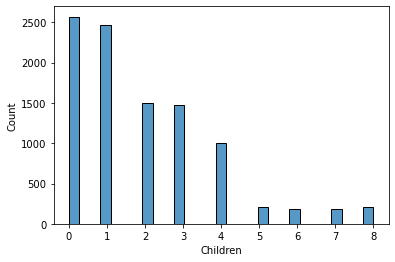

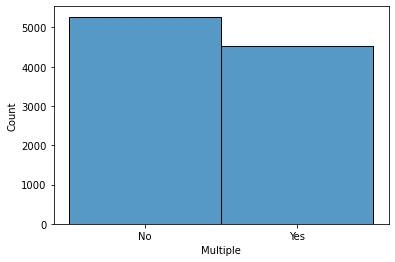

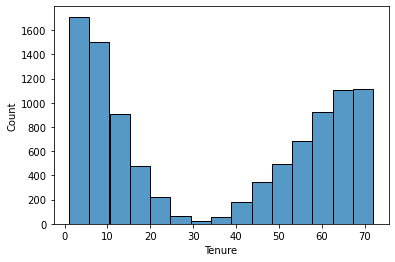

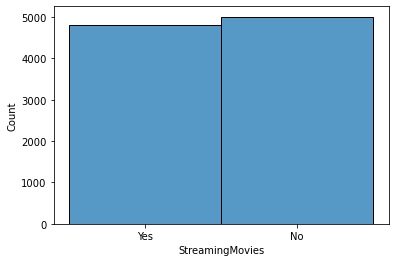

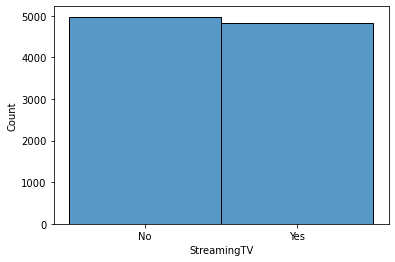

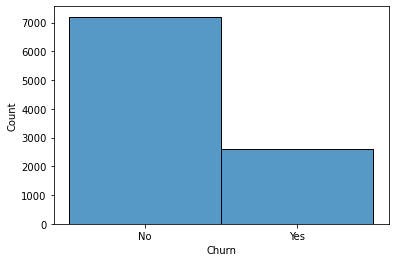

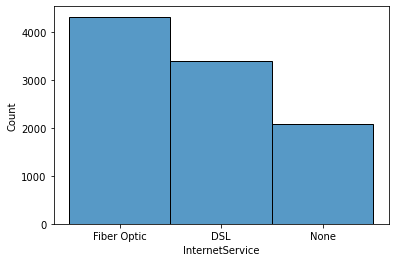

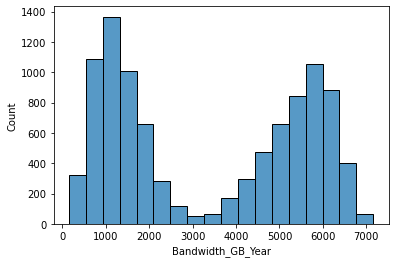

In [41]:
#Visualizing Univariate Distributions
for i in data.columns:
    sns.histplot(data = data, x = i)
    plt.show()

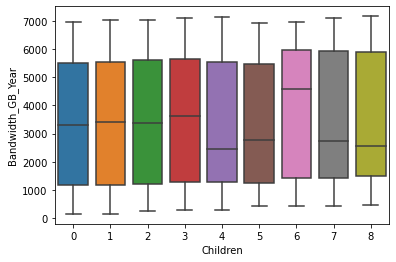

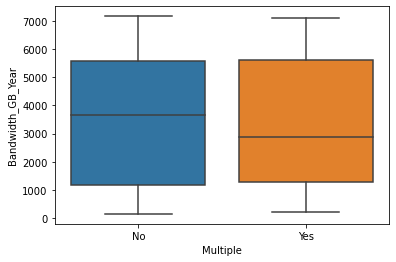

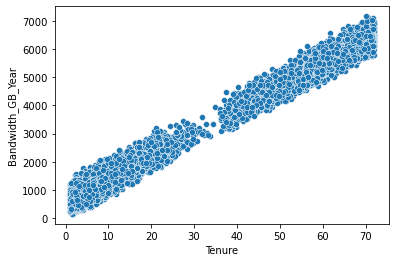

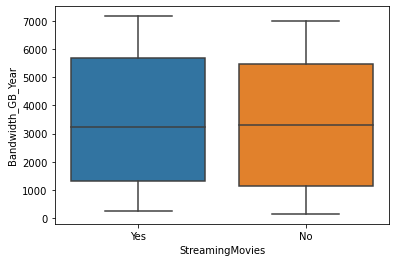

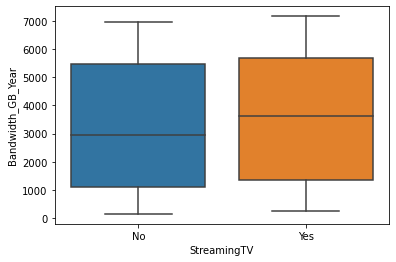

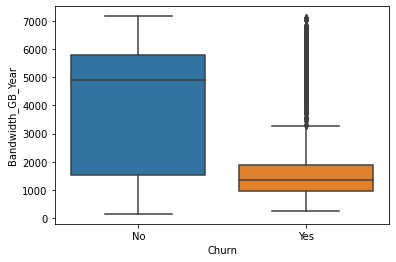

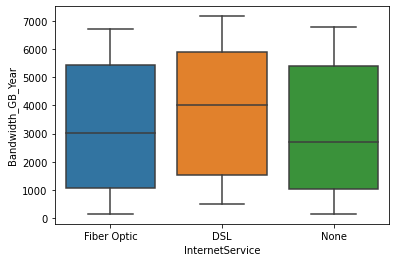

In [42]:
#Collecting categorical columns for dummy variables and ordinal encoding 
cat_cols = []

#Visualizing bivariate distributions of variables paired with Bandwidth_GB_Year
for i in data.columns:
    if i in ['Tenure','Income']:
        sns.scatterplot(data = data, x = i, y = 'Bandwidth_GB_Year')
        plt.show()
    elif i != 'Bandwidth_GB_Year':
        sns.boxplot(data = data, x = i, y = 'Bandwidth_GB_Year')
        cat_cols.append(i)
        plt.show()

# Categorical Variable Transformation

In [43]:
#Ordinal Encoding
for i in cat_cols:
    if i not in ['InternetService','Children']:
        data[i] = data[i].map({"Yes":1,"No":0}) 
#Dummy Variables
data = pd.get_dummies(data)
data = data.drop(columns = ['InternetService_None'])

# Assessing Multicollinearity

In [44]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [45]:
X_cols = [x for x in data.columns if x not in ['Bandwidth_GB_Year']]
y = data['Bandwidth_GB_Year']
X = data[X_cols].copy(deep = True)
print([(X.columns[i],variance_inflation_factor(X.values,i)) for i in range(len(X.columns))])

[('Children', 1.8358157160180546), ('Multiple', 1.798183110510184), ('Tenure', 3.0107229624614473), ('StreamingMovies', 2.1418837017204515), ('StreamingTV', 2.0311694892328744), ('Churn', 2.164282827396203), ('InternetService_DSL', 2.020868744377912), ('InternetService_Fiber Optic', 2.176524376376824)]


In [46]:
data.to_csv("D:\DataProjects\WGU\Data Mining I\\task_2_clean.csv")

# Splitting test and training data

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = .3, random_state = 1000)

In [48]:
t = X_train.copy(deep = True)
t['Bandwidth_GB_Year'] = y_train
test = X_test.copy(deep = True)
test['Bandwidt_GB_Year'] = y_test

In [49]:
t.to_csv("D:\DataProjects\WGU\Data Mining I\\task_2_training.csv")
test.to_csv("D:\DataProjects\WGU\Data Mining I\\task_2_test.csv")

# Hyperparameter Tuning

In [50]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

In [51]:
params = {
    "alpha":[.1,.2,.3,.4,.5,.6,.7,.8,.9]
}
estimator = Ridge()
ridge_grid = GridSearchCV(estimator,params,scoring= 'explained_variance')
ridge_grid.fit(X_train,y_train)

GridSearchCV(estimator=Ridge(),
             param_grid={'alpha': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8,
                                   0.9]},
             scoring='explained_variance')

In [52]:
print('Best Model',ridge_grid.best_params_)
print('Score',ridge_grid.best_score_)

Best Model {'alpha': 0.3}
Score 0.9975698910823653


In [53]:
estimator = Ridge(alpha  = .3)
estimator.fit(X_train,y_train)
y_pred = estimator.predict(X_test)

In [54]:
r2 = cross_val_score(estimator, X_test,y_test,scoring = 'r2').mean()
mae = cross_val_score(estimator, X_test,y_test,scoring = 'neg_mean_absolute_error').mean()
mse = cross_val_score(estimator, X_test,y_test,scoring = 'neg_mean_squared_error').mean()

In [55]:
print(r2)
print(-mae)
print(-mse)

0.9974900042001271
88.72315562082804
11784.819804913912


# Model Performance Analysis

- R-squared is very high indicating the model is suffering from overfitting despite the Ridge       regularization. 



- We use the mean absolute error metric as the preferred metric because mean squared error is so much larger.

In [56]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

In [57]:
print('Test Performance')
print("R-Squared",r2_score(y_test,y_pred))
print('Mean Absolute Error',mean_absolute_error(y_test,y_pred))
print("Mean Squared Error",mean_squared_error(y_test,y_pred))
print("\nTest Performance Cross Validation")
r2_test = cross_val_score(estimator, X_test,y_test,scoring = 'r2').mean()
mae_test = cross_val_score(estimator, X_test,y_test,scoring = 'neg_mean_absolute_error').mean()
mse_test = cross_val_score(estimator, X_test,y_test,scoring = 'neg_mean_squared_error').mean()
print("R-Squared",r2_test)
print('Mean Absolute Error',-mae_test)
print("Mean Squared Error",-mse_test,'\n')

Test Performance
R-Squared 0.9974979211396378
Mean Absolute Error 88.60144079633491
Mean Squared Error 11756.717448081668

Test Performance Cross Validation
R-Squared 0.9974900042001271
Mean Absolute Error 88.72315562082804
Mean Squared Error 11784.819804913912 



In [58]:
(11756+11784)/2

11770.0

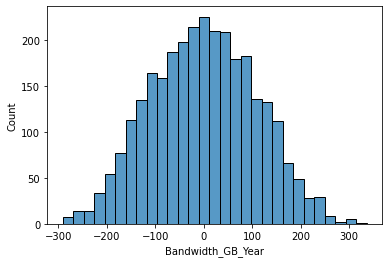

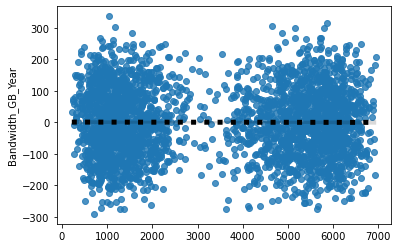

In [59]:
residuals = (y_test-y_pred)
sns.histplot(x = residuals)
plt.show()
sns.regplot(x = y_pred, y = residuals,
            line_kws = {'color':'black','linestyle':'dotted','linewidth':5})
plt.show()

In [60]:
estimator.coef_

array([ 31.84158581,  70.30467945,  82.06884625, 203.60241197,
       221.65100076,  23.59577613, 411.04408954,  -3.17406194])

In [61]:
model_summary = {
    'Intercept':estimator.intercept_,
    'Feature':[],
    'Coefficient':[]
}
for i in X_train.columns:
    model_summary['Feature'].append(i)
    model_summary['Coefficient'].append(estimator.coef_[list(X_train.columns).index(i)])
    
model_summary = pd.DataFrame(model_summary)

In [62]:
model_summary

,Intercept,Feature,Coefficient
0,103.90157,Children,31.841586
1,103.90157,Multiple,70.304679
2,103.90157,Tenure,82.068846
3,103.90157,StreamingMovies,203.602412
4,103.90157,StreamingTV,221.651001
5,103.90157,Churn,23.595776
6,103.90157,InternetService_DSL,411.044090
7,103.90157,InternetService_Fiber Optic,-3.174062


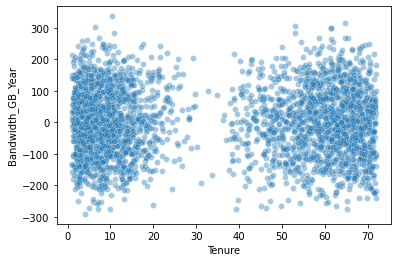

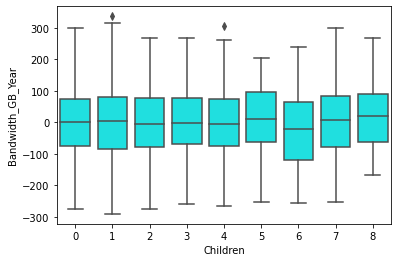

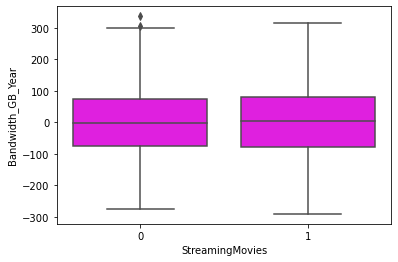

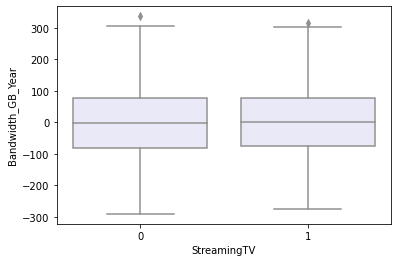

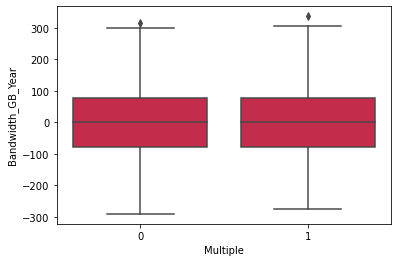

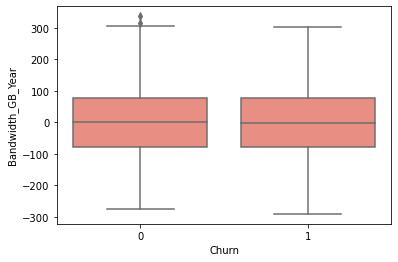

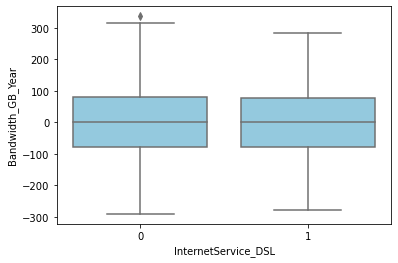

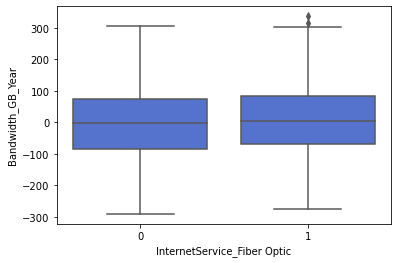

In [63]:
sns.scatterplot(x = X_test['Tenure'],y = residuals,alpha = .4)
plt.show()
sns.boxplot(x = X_test['Children'],y = residuals, color = 'aqua')
plt.show()
sns.boxplot(x = X_test['StreamingMovies'],y = residuals, color = 'magenta')
plt.show()
sns.boxplot(x = X_test['StreamingTV'],y = residuals, color = 'lavender')
plt.show()
sns.boxplot(x = X_test['Multiple'],y = residuals, color = 'crimson')
plt.show()
sns.boxplot(x = X_test['Churn'],y = residuals, color = 'salmon')
plt.show()
sns.boxplot(x = X_test['InternetService_DSL'],y = residuals, color = 'skyblue')
plt.show()
sns.boxplot(x = X_test['InternetService_Fiber Optic'],y = residuals, color = 'royalblue')
plt.show()

In [64]:
discrete = ['Children','Multiple','StreamingMovies',
            'StreamingTV','Churn','InternetService_DSL','InternetService_Fiber Optic']
X_test['Residuals'] = residuals
for i in discrete:
    print(X_test.groupby(i)['Residuals'].describe())

          count       mean         std         min         25%        50%  \
Children                                                                    
0         790.0  -0.199556  105.569361 -275.628438  -75.243707  -0.195162   
1         731.0  -1.060209  112.082475 -291.146165  -85.613771   4.328319   
2         464.0  -1.479454  107.993953 -274.368465  -79.702342  -4.541815   
3         413.0   1.634782  105.328450 -259.178353  -69.384095  -0.883595   
4         299.0   0.390962  107.458688 -265.306140  -74.015802  -4.989477   
5          70.0  11.734844  110.442062 -254.649884  -64.199994   8.892701   
6          56.0 -24.168210  116.987326 -256.618443 -119.440919 -20.634555   
7          56.0   2.694393  123.395419 -254.742024  -78.171463   6.037852   
8          64.0  20.307063  106.934865 -166.514891  -61.219401  18.486266   

                75%         max  
Children                         
0         75.180270  298.830848  
1         81.690802  336.676700  
2         77.883